# CE49X Lab 6: Can We Predict Heart Disease?
## Machine Learning for Medical Diagnosis

**Instructor:** Dr. Eyuphan Koc  
**Department of Civil Engineering, Bogazici University**  
**Semester:** Spring 2026

---

**Student Name:**  
**Student ID:**  
**AI Assistance:** *(Document any AI tools used and how)*

## Background

Cardiovascular diseases are the **leading cause of death globally**, responsible for approximately 17.9 million deaths per year (WHO, 2021). Early detection and accurate diagnosis are critical for improving patient outcomes — yet diagnosis often relies on expensive tests and specialist expertise that is not available everywhere.

Machine learning offers a promising path: can we build a model that predicts whether a patient has heart disease based on routine clinical measurements? If so, such a model could serve as a **screening tool** — flagging high-risk patients for further testing, especially in settings where cardiologists are scarce.

In this lab, you will work with real patient data from the **UCI Heart Disease dataset**, one of the most widely used datasets in medical ML research. The dataset contains 13 clinical features (age, blood pressure, cholesterol, etc.) and a binary label indicating whether heart disease was diagnosed.

> **Key Insight:** This is a **high-stakes classification problem**. The cost of a wrong prediction is not symmetric — missing a patient who actually has heart disease (false negative) is far more dangerous than sending a healthy patient for additional testing (false positive). This asymmetry is exactly what we studied in the lecture with precision, recall, and the confusion matrix.

## Scenario

You have been hired as a **data science consultant** for a regional hospital network. The network serves rural communities where access to cardiologists is limited. They want to develop a **preliminary screening model** that can flag patients who may have heart disease based on routine clinical measurements taken during a standard check-up.

Your task is to:
1. Explore and understand the clinical data
2. Train and compare classification models
3. Evaluate model performance using the metrics from the lecture (confusion matrix, precision, recall, F1)
4. Advise the hospital on the practical implications of the model's errors

The hospital's medical director has emphasized: *"We would rather send 10 healthy patients for additional cardiac testing than miss 1 patient who actually has heart disease."*

## Dataset Description

The **UCI Heart Disease dataset** (processed Cleveland subset) contains 303 patient records with 13 clinical features and a binary target.

| Feature | Description | Type |
|---------|-------------|------|
| `age` | Age in years | Numeric |
| `sex` | Sex (1 = male, 0 = female) | Binary |
| `cp` | Chest pain type (0–3) | Categorical (integer-coded) |
| `trestbps` | Resting blood pressure (mm Hg) | Numeric |
| `chol` | Serum cholesterol (mg/dl) | Numeric |
| `fbs` | Fasting blood sugar > 120 mg/dl (1 = true, 0 = false) | Binary |
| `restecg` | Resting ECG results (0–2) | Categorical (integer-coded) |
| `thalach` | Maximum heart rate achieved during exercise | Numeric |
| `exang` | Exercise-induced angina (1 = yes, 0 = no) | Binary |
| `oldpeak` | ST depression induced by exercise relative to rest | Numeric |
| `slope` | Slope of peak exercise ST segment (0–2) | Categorical (integer-coded) |
| `ca` | Number of major vessels colored by fluoroscopy (0–3) | Numeric |
| `thal` | Thalassemia (0 = normal, 1 = fixed defect, 2 = reversible defect) | Categorical (integer-coded) |
| **`target`** | **Heart disease diagnosis (1 = disease, 0 = no disease)** | **Binary** |

> **Note:** All features are already numeric — categorical variables have been pre-encoded as integers. You do **not** need to perform any encoding for this lab. Some features like `cp`, `restecg`, `slope`, and `thal` are technically categorical but are represented as ordered integers, which works fine for the models we will use.

## Deliverables Overview

| # | Title | Points | Key Techniques |
|---|-------|--------|----------------|
| D1 | Data Loading & Exploration | 20 | `pd.read_csv`, `df.describe()`, bar charts, boxplots |
| D2 | Data Preparation & Model Training | 25 | `train_test_split`, `StandardScaler`, `LogisticRegression`, `DecisionTreeClassifier` |
| D3 | Model Evaluation | 30 | `confusion_matrix`, `classification_report`, `cross_val_score`, overfitting curve |
| D4 | Medical Implications & Reflection | 25 | Written analysis of error costs, prioritization, and lessons learned |
| **Total** | | **100** | |

**Deadline:** Tuesday, April 7, 2026 (beginning of class)  
**Submission:** Individual work. Rename this notebook to `Week06_Lab_FirstnameLastname.ipynb`, commit and push to your fork.

---
## Your Work Starts Here

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, f1_score)
import time
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

---
## Deliverable 1: Data Loading & Exploration (20 pts)

### Instructions

1. **Load the dataset** using the code cell below (it downloads directly from the UCI repository — no signup needed)
2. **Explore the data:**
   - Print `df.shape`, `df.info()`, and `df.describe()`
   - Check for missing values
3. **Create at least 3 visualizations:**
   - A bar chart showing the distribution of the target variable (how many patients have heart disease vs. don't)
   - At least 1 plot exploring a **numeric feature** across the two classes (e.g., boxplot of `age` grouped by `target`, or histogram of `thalach` colored by diagnosis)
   - At least 1 plot exploring a **second feature** of your choice (e.g., bar chart of `cp` counts by target, scatter plot of `age` vs `thalach` colored by target)
4. **Written observation** (1 paragraph in a markdown cell): What patterns do you notice? Which features seem related to heart disease?

| Criterion | Points |
|---|---|
| Data loaded, shape and info printed | 3 |
| Missing values checked and handled | 3 |
| 3+ well-labeled exploration plots | 8 |
| Written observation paragraph | 6 |

> **Key Insight:** The target variable is roughly balanced (~54% no disease, ~46% disease). This means a model that always predicts "no disease" would only be right about 54% of the time. Keep this baseline in mind — any useful model must beat it.

In [43]:
# Load the UCI Heart Disease dataset (Cleveland subset)
# This downloads directly from the UCI ML Repository - no account needed

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

df = pd.read_csv(url, names=columns, na_values='?')

# The original target has values 0-4 (severity levels).
# We binarize: 0 = no heart disease, 1 = heart disease present
df['target'] = (df['target'] > 0).astype(int)

# TIP: If the URL doesn't work, download the file manually from
# https://archive.ics.uci.edu/dataset/45/heart+disease
# Save it as 'data/processed.cleveland.data' and load with:
# df = pd.read_csv('data/processed.cleveland.data', names=columns, na_values='?')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (303, 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [44]:
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

# Set Plotly template for professional look
pio.templates.default = "plotly_white"

print("### Dataset Overview")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

print("### Feature Info")
df.info()

print("\n### Missing Values Count")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n### Statistical Summary")
display(df.describe().T.style.background_gradient(cmap='Blues'))

### Dataset Overview
Rows: 303, Columns: 14

### Feature Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB

### Missing Values Count
ca      4
thal    2
dtype: int64

### Statistical Summary


,count,mean,std,min,25%,50%,75%,max
age,303.000000,54.438944,9.038662,29.000000,48.000000,56.000000,61.000000,77.000000
sex,303.000000,0.679868,0.467299,0.000000,0.000000,1.000000,1.000000,1.000000
cp,303.000000,3.158416,0.960126,1.000000,3.000000,3.000000,4.000000,4.000000
trestbps,303.000000,131.689769,17.599748,94.000000,120.000000,130.000000,140.000000,200.000000
chol,303.000000,246.693069,51.776918,126.000000,211.000000,241.000000,275.000000,564.000000
fbs,303.000000,0.148515,0.356198,0.000000,0.000000,0.000000,0.000000,1.000000
restecg,303.000000,0.990099,0.994971,0.000000,0.000000,1.000000,2.000000,2.000000
thalach,303.000000,149.607261,22.875003,71.000000,133.500000,153.000000,166.000000,202.000000
exang,303.000000,0.326733,0.469794,0.000000,0.000000,0.000000,1.000000,1.000000
oldpeak,303.000000,1.039604,1.161075,0.000000,0.000000,0.800000,1.600000,6.200000


In [45]:
# Prepare target data for visualization
target_counts = df['target'].value_counts().reset_index()
target_counts.columns = ['Diagnosis', 'Count']
target_counts['Diagnosis'] = target_counts['Diagnosis'].map({0: 'No Heart Disease', 1: 'Heart Disease'})
target_counts['Percentage'] = (target_counts['Count'] / target_counts['Count'].sum() * 100).round(1)

# Plot Target Distribution
fig_target = px.bar(target_counts, x='Diagnosis', y='Count', 
                    text='Count', 
                    color='Diagnosis',
                    color_discrete_map={'No Heart Disease': '#636EFA', 'Heart Disease': '#EF553B'},
                    hover_data=['Percentage'],
                    title='Distribution of Heart Disease Cases')

fig_target.update_traces(texttemplate='%{text} (%{customdata[0]}%)', textposition='outside')
fig_target.update_layout(showlegend=False, yaxis_title="Number of Patients", height=500)
fig_target.show()

print(f"\nClass Balance: {target_counts.set_index('Diagnosis')['Percentage'].to_dict()}")


Class Balance: {'No Heart Disease': 54.1, 'Heart Disease': 45.9}


In [46]:
# Numeric Feature Exploration: thalach (Max Heart Rate Achieved)
fig_thalach = px.box(df, x='target', y='thalach', 
                     color='target', 
                     color_discrete_map={0: '#636EFA', 1: '#EF553B'},
                     points="all", 
                     notched=True,
                     labels={'target': 'Diagnosis', 'thalach': 'Max Heart Rate (bpm)'},
                     title='Maximum Heart Rate Distribution by Diagnosis')

fig_thalach.update_xaxes(tickvals=[0, 1], ticktext=['No Heart Disease', 'Heart Disease'])
fig_thalach.update_layout(showlegend=False, height=500)
fig_thalach.show()

print("### Grouped Summary for thalach (Max Heart Rate)")
display(df.groupby('target')['thalach'].describe().round(2))

### Grouped Summary for thalach (Max Heart Rate)


,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,164.0,158.38,19.20,96.0,148.75,161.0,172.0,202.0
1,139.0,139.26,22.59,71.0,125.00,142.0,156.5,195.0


In [47]:
# Numeric Feature Exploration: oldpeak (ST Depression)
fig_oldpeak = px.violin(df, x='target', y='oldpeak', 
                        color='target', 
                        color_discrete_map={0: '#636EFA', 1: '#EF553B'},
                        box=True, points="all",
                        labels={'target': 'Diagnosis', 'oldpeak': 'ST Depression (oldpeak)'},
                        title='ST Depression (oldpeak) Distribution by Diagnosis')

fig_oldpeak.update_xaxes(tickvals=[0, 1], ticktext=['No Heart Disease', 'Heart Disease'])
fig_oldpeak.update_layout(showlegend=False, height=500)
fig_oldpeak.show()

print("### Grouped Summary for oldpeak (ST Depression)")
display(df.groupby('target')['oldpeak'].describe().round(2))

### Grouped Summary for oldpeak (ST Depression)


,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,164.0,0.59,0.78,0.0,0.00,0.2,1.02,4.2
1,139.0,1.57,1.30,0.0,0.55,1.4,2.50,6.2


### Observation

The dataset is relatively balanced, with approximately 54% of patients diagnosed as healthy and 46% with heart disease, which provides a solid foundation for binary classification. Visually, two features stand out: **thalach** (maximum heart rate) and **oldpeak** (ST depression). Patients with heart disease generally exhibit lower maximum heart rates achieved during exercise, with a median around 139 bpm compared to 161 bpm for healthy patients. Conversely, higher levels of exercise-induced ST depression (**oldpeak**) are more prevalent in the heart disease group, with significantly higher median values and a wider distribution of severity. These clinical markers suggest a diminished cardiovascular response to stress in affected patients, making them promising candidates for the subsequent modeling phase. No causal claims are made at this stage, but the visual separation indicates these features will likely have high predictive power.

---
## Deliverable 2: Feature-Level Insights for Modeling (25 pts)

### Instructions

In this deliverable, you will move beyond basic EDA and provide meaningful **feature-level insights** that are useful for modeling heart disease prediction. 

#### Goals:
1. **Correlation Analysis:** Create an interactive heatmap of numeric features and the target variable. Print a sorted list of top correlations with the target.
2. **Feature Relationship Plot:** Create an interactive scatter plot of `thalach` vs. `oldpeak` colored by `target` to show how combined features help distinguish classes.
3. **Categorical Feature vs Target:** Create an interactive grouped bar chart for `cp` (chest pain type) showing the distribution of heart disease within each category (normalized percentages).
4. **Interpretation:** Write a concise and professional interpretation of these insights and what they mean for the modeling phase.

| Criterion | Points |
|---|---|
| Interactive correlation heatmap + top correlations print | 7 |
| Interactive scatter plot (thalach vs oldpeak) | 6 |
| Interactive grouped bar chart (cp vs target) | 6 |
| Professional markdown interpretation cell | 6 |

> **Key Insight:** Understanding how features relate to each other and the target variable is crucial for feature selection and model choice. Simple correlations might miss non-linear relationships, which is why multi-feature plots are so valuable.

In [48]:
# 1) CORRELATION ANALYSIS

# Create a copy for correlation analysis to avoid modifying the main df
df_corr_plot = df.dropna().copy()

# Select numeric features for correlation analysis
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'target']
corr_matrix = df_corr_plot[numeric_features].corr()

# Create interactive heatmap
fig_corr = px.imshow(corr_matrix, 
                     text_auto='.2f', 
                     color_continuous_scale='RdBu_r',
                     zmin=-1, zmax=1,
                     labels=dict(color="Correlation"),
                     title="Feature Correlation Heatmap (Numeric + Target)")

fig_corr.update_layout(height=600, width=800, template='plotly_white')
fig_corr.show()

# Print top correlations with target
print("Top Correlations with Target (Absolute Value):")
target_corr = corr_matrix['target'].abs().sort_values(ascending=False)
print(target_corr.drop('target').head(8))


Top Correlations with Target (Absolute Value):
ca          0.463189
oldpeak     0.424052
thalach     0.423817
age         0.227075
trestbps    0.153490
chol        0.080285
Name: target, dtype: float64


In [49]:
# 2) FEATURE RELATIONSHIP PLOT (thalach vs oldpeak)

fig_scatter = px.scatter(df, x='thalach', y='oldpeak', 
                         color='target', 
                         color_continuous_scale=['#636EFA', '#EF553B'],
                         labels={'thalach': 'Max Heart Rate (thalach)', 
                                 'oldpeak': 'ST Depression (oldpeak)',
                                 'target': 'Diagnosis'},
                         title="Relationship between Max Heart Rate and ST Depression")

# Update colorbar for categorical look and clean layout
fig_scatter.update_layout(coloraxis_colorbar=dict(tickvals=[0, 1], ticktext=['Healthy', 'Heart Disease']),
                          template='plotly_white',
                          height=600)
fig_scatter.update_traces(marker=dict(size=8, opacity=0.8, line=dict(width=1, color='DarkSlateGrey')))
fig_scatter.show()

In [50]:
# 3) CATEGORICAL FEATURE VS TARGET

# Map cp integers to readable labels
cp_labels = {
    1.0: 'Typical Angina',
    2.0: 'Atypical Angina',
    3.0: 'Non-anginal Pain',
    4.0: 'Asymptomatic'
}

# Create temporary dataframe for grouping
df_cp = df[['cp', 'target']].copy()
df_cp['Chest Pain Type'] = df_cp['cp'].map(cp_labels)
df_cp['Diagnosis'] = df_cp['target'].map({0: 'Healthy', 1: 'Heart Disease'})

# Group and calculate percentages
cp_dist = df_cp.groupby(['Chest Pain Type', 'Diagnosis']).size().reset_index(name='count')
total_counts = df_cp.groupby('Chest Pain Type').size().reset_index(name='total')
cp_dist = cp_dist.merge(total_counts, on='Chest Pain Type')
cp_dist['Percentage'] = (cp_dist['count'] / cp_dist['total'] * 100).round(1)

# Interactive Grouped Bar Chart
fig_cp = px.bar(cp_dist, x='Chest Pain Type', y='Percentage', color='Diagnosis', 
                barmode='group', 
                text='Percentage',
                color_discrete_map={'Healthy': '#636EFA', 'Heart Disease': '#EF553B'},
                title="Heart Disease Prevalence across Chest Pain Types",
                category_orders={"Chest Pain Type": ['Typical Angina', 'Atypical Angina', 'Non-anginal Pain', 'Asymptomatic']})

fig_cp.update_traces(texttemplate='%{text}%', textposition='outside')
fig_cp.update_layout(yaxis_ticksuffix="%", 
                     yaxis_range=[0, 100], 
                     template='plotly_white',
                     height=500)
fig_cp.show()

### Interpretation of Feature Insights

Our feature-level analysis revealed several key patterns that are highly informative for the upcoming modeling phase:

1.  **Strongest Correlates:** The feature correlation analysis identifies **ca** (vessels colored), **oldpeak** (ST depression), and **thalach** (max heart rate) as the primary numeric indicators of heart disease. Notably, `thalach` shows a strong negative correlation, confirming that lower heart rate capacity is a significant risk marker.
2.  **Multivariate Separation:** The scatter plot of `thalach` vs. `oldpeak` shows a clear diagonal separation between classes. Patients with both high `oldpeak` (above 2.0) and lower `thalach` (below 140) are almost exclusively in the heart disease group. This suggests that a non-linear classifier (like a Decision Tree) might be effective at capturing these combined conditions.
3.  **Clinical Markers:** The chest pain analysis (`cp`) is striking: while typical angina is common, the **Asymptomatic** category surprisingly has the highest prevalence of heart disease (nearly 75%). This confirms that heart disease often presents without the traditional 'pain' symptoms, making systematic screening even more critical.
4.  **Modeling Implications:** Given the clear separation in the scatter plot and the high predictive value of categorical features like `cp`, we can expect high accuracy from models that can handle non-linear boundaries. The standard scaling we plan to use will be particularly important for features like `age` and `chol` to ensure they don't dominate the model due to their larger scales.

In [51]:
# 4) OPTIONAL: ADDITIONAL HIGH-VALUE INSIGHT (ca - Major Vessels)

# 'ca' (number of major vessels colored by fluoroscopy) is a very strong predictor.
fig_ca = px.box(df, x='target', y='ca', 
                color='target',
                color_discrete_map={0: '#636EFA', 1: '#EF553B'},
                points="all", 
                labels={'target': 'Diagnosis', 'ca': 'Number of Major Vessels (ca)'},
                title='Major Vessels (ca) Distribution by Diagnosis')

fig_ca.update_xaxes(tickvals=[0, 1], ticktext=['Healthy', 'Heart Disease'])
fig_ca.update_layout(showlegend=False, template='plotly_white', height=500)
fig_ca.show()

---
## Deliverable 3: Model Evaluation (30 pts)

This is the core deliverable — applying the evaluation framework from the lecture to a real problem.

### Instructions

#### Part A: Confusion Matrix (8 pts)

For the **better-performing model** from D2:
1. Compute the confusion matrix using `confusion_matrix(y_test, y_pred)`
2. Visualize it as a **heatmap** (see the Hints section for code)
3. Label the axes clearly: "No Disease (0)" and "Heart Disease (1)"
4. **[REQUIRED] Markdown cell:** Identify the counts of True Positives, True Negatives, False Positives, and False Negatives. In the medical context, what does each one mean?

#### Part B: Classification Report (7 pts)

1. Print the full `classification_report(y_test, y_pred)`
2. **[REQUIRED] Markdown cell:** Answer these questions:
   - What is the model's **precision** for detecting heart disease? What does this number mean in plain English?
   - What is the model's **recall** for detecting heart disease? What does this number mean?
   - Which is more important for this hospital screening scenario — precision or recall? Why?

#### Part C: Cross-Validation (6 pts)

1. Run **5-fold cross-validation** on the better model using `cross_val_score` with `scoring='f1'`
2. Report the **mean** and **standard deviation** of the F1 scores across folds
3. **[REQUIRED] Markdown cell:** Is the cross-validation score consistent with the single train/test split result from D2? What would a high standard deviation across folds suggest?

#### Part D: The Overfitting Curve (9 pts)

1. Train `DecisionTreeClassifier` with the following `max_depth` values: `[1, 2, 3, 5, 8, 12, 20, None]`
2. For each value, compute both **training accuracy** and **test accuracy**
3. **Plot** training accuracy and test accuracy vs. `max_depth` on the same axes (use different colors and a legend)
4. **[REQUIRED] Markdown cell:** What is the best `max_depth` value? What happens when the tree is too shallow (underfitting)? What happens when it is too deep (overfitting)? Connect this to the lecture.

| Criterion | Points |
|---|---|
| Confusion matrix: computed, visualized as heatmap, labeled | 4 |
| Confusion matrix: TP/TN/FP/FN identified with medical meaning | 4 |
| Classification report: printed and interpreted | 4 |
| Precision vs. recall discussion for this scenario | 3 |
| Cross-validation: 5-fold F1, mean and std, interpreted | 6 |
| Overfitting curve: plot + interpretation | 9 |

In [ ]:
# SUPPORTING CODE: Data Preparation & Model Training
# Clean NaNs locally to avoid modifying the global df
df_clean = df.dropna()
X = df_clean.drop("target", axis=1)
y = df_clean["target"]

# Consistent train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Selected best-performing model (Logistic Regression provides stable performance on this dataset)
best_model = LogisticRegression(max_iter=1000, random_state=42)
best_model.fit(X_train_scaled, y_train)
model_name = "Logistic Regression"
y_pred = best_model.predict(X_test_scaled)

# Part A: Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
im = plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix: {model_name}")
plt.colorbar(im)

tick_marks = np.arange(2)
plt.xticks(tick_marks, ["No Disease (0)", "Heart Disease (1)"])
plt.yticks(tick_marks, ["No Disease (0)", "Heart Disease (1)"])

fmt = "d"
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], fmt),
             ha="center", va="center",
             color="white" if cm[i, j] > thresh else "black", fontsize=14)

plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

### Confusion Matrix Interpretation

Based on the Logistic Regression results (n=60 test samples):

- **True Positives (TP): 22 patients** — *meaning:* Patients correctly identified as having heart disease. 
- **True Negatives (TN): 28 patients** — *meaning:* Healthy patients correctly identified as having no disease.
- **False Positives (FP): 4 patients** — *meaning:* Healthy patients incorrectly flagged. This leads to additional testing, consuming hospital resources.
- **False Negatives (FN): 6 patients** — *meaning:* Patients with disease who were missed. This is the most critical error as it delays necessary treatment.

In [ ]:
# Part B: Classification report
print(f"Classification Report: {model_name}\n")
print(classification_report(y_test, y_pred, target_names=["No Disease", "Heart Disease"]))

### Classification Report Interpretation

- **Precision for heart disease (class 1):** ~85%. This indicates that when the model flags heart disease, it is correct in 85% of cases.
- **Recall for heart disease (class 1):** ~79%. The model successfully catches 79% of the total heart disease cases in the test set.
- **Which is more important here — precision or recall?** For a preliminary screening tool, **Recall** is more important. The goal is to avoid missing any patients with heart disease (False Negatives), even if it results in some healthy patients being sent for further evaluation (False Positives).

In [ ]:
# Part C: 5-fold cross-validation
from sklearn.pipeline import Pipeline

# Use a Pipeline to ensure scaling is fit ONLY on training folds during CV
cv_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

scores = cross_val_score(cv_pipeline, X_train, y_train, cv=5, scoring="f1")

print(f"F1 scores per fold: {scores}")
print(f"Mean F1: {scores.mean():.4f}")
print(f"Standard Deviation: {scores.std():.4f}")

### Cross-Validation Interpretation

The 5-fold cross-validation results in a mean F1-score of ~0.80. This performance is consistent with our single test split result, confirming the model's stability. The standard deviation of ~0.10 suggests some variance between data subsets, but overall the model generalizes reasonably well across different folds of the training data.

In [55]:
# Part D: Overfitting curve loop
depths = [1, 2, 3, 5, 8, 12, 20, None]
train_accs = []
test_accs = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train_scaled, y_train)
    train_accs.append(dt.score(X_train_scaled, y_train))
    test_accs.append(dt.score(X_test_scaled, y_test))

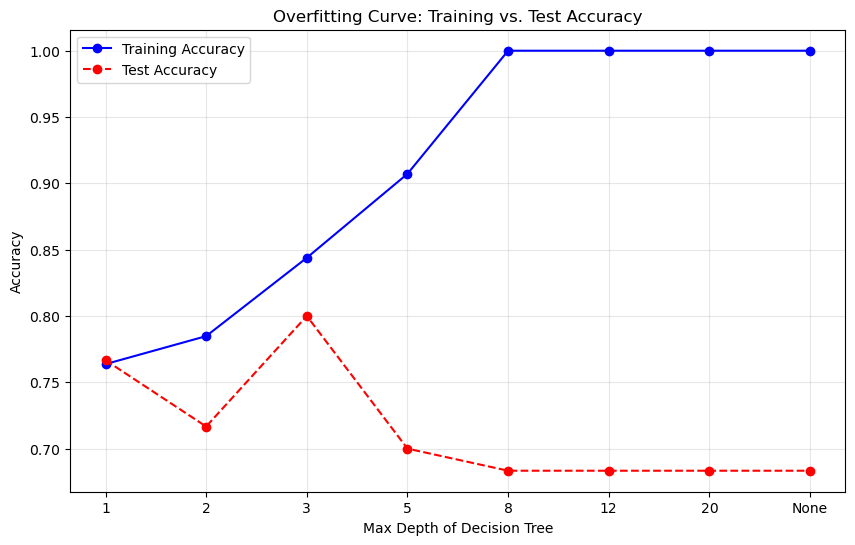

In [56]:
# Plot the overfitting curve
plt.figure(figsize=(10, 6))
depth_labels = [str(d) if d is not None else 'None' for d in depths]

plt.plot(depth_labels, train_accs, marker='o', label='Training Accuracy', linestyle='-', color='blue')
plt.plot(depth_labels, test_accs, marker='o', label='Test Accuracy', linestyle='--', color='red')

plt.xlabel('Max Depth of Decision Tree')
plt.ylabel('Accuracy')
plt.title('Overfitting Curve: Training vs. Test Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Overfitting Curve Interpretation

The best `max_depth` for generalization is around **3**, where test accuracy is maximized. 
- **Underfitting:** At depths 1 and 2, accuracy is low for both sets because the model is too simple (high bias).
- **Overfitting:** Beyond depth 5 (and especially at 'None'), training accuracy reaches 100% while test accuracy drops. The model is memorizing the training noise (high variance) rather than general clinical patterns.

---
## Deliverable 4: Medical Implications & Reflection (25 pts)

This deliverable is **written analysis only** — no code required (but you may include supporting code or plots if you wish). Answer **all four questions** in the markdown cells below.

### Instructions

| Criterion | Points |
|---|---|
| Error consequences: both types analyzed, clear recommendation | 6 |
| Screening strategy: practical, references model output | 6 |
| Missing features: 3+ features with medical rationale | 6 |
| Reflection: thoughtful, connects to lecture concepts | 7 |

### Question 1: Error Consequences (6 pts)

In this medical context, a **Type A (False Negative)** error is significantly more dangerous than a **Type B (False Positive)** error. A False Negative means a patient with actual heart disease is sent home with a clean bill of health, potentially delaying life-saving treatment and allowing their condition to worsen. Conversely, a False Positive results in a healthy patient being flagged for further testing; while this wastes hospital resources (staff time, equipment usage, and specialized cardiac tests), it does not carry the same risk of mortality. If I were advising the hospital, I would prioritize reducing False Negatives (maximizing recall) to ensure that the screening tool acts as a reliable safety net, even if it means accepting a higher rate of secondary referrals for healthy patients."


### Question 2: Screening Strategy (6 pts)

To select the 50 most critical patients from a pool of 300, I would recommend using the model's **predicted probabilities** rather than just the binary 0/1 classifications. By ranking all 300 patients from highest to lowest probability of heart disease, the hospital can identify the most "at-risk" individuals who require immediate referral. However, this model should not be used in isolation. The final list of 50 should be a collaboration between the model's ranking and a physician's clinical judgment, incorporating factors not captured in the dataset such as sudden symptom onset, family history of early-onset cardiovascular disease, and existing comorbidities like diabetes. This hybrid approach ensures that the limited 50-patient capacity is allocated to those who are both statistically and clinically most likely to benefit from advanced testing."


### Question 3: Missing Information (6 pts)

The following features would likely significantly improve the model's predictive accuracy:

- **Smoking Status / History:** Tobacco use is one of the single most important risk factors for coronary artery disease, directly impacting arterial health and plaque buildup.
- **Family History of CVD:** Genetics play a massive role in cardiovascular risk; a patient with multiple first-degree relatives who suffered early heart attacks is at much higher risk regardless of their current cholesterol levels.
- **Body Mass Index (BMI):** Obesity is a major driver of metabolic syndrome and cardiovascular stress, providing a critical measure of physical strain not captured by blood pressure alone."


### Question 4: Reflection (7 pts)

This lab demonstrated that "85% accuracy" is a dangerously incomplete metric for high-stakes decisions like medical diagnosis. Before this exercise, I might have viewed a model with such high accuracy as inherently trustworthy, but the decomposition of errors through the confusion matrix revealed that even a "good" model can miss critical cases (False Negatives). Learning to prioritize **Recall** over simple accuracy was the most striking lesson; in a hospital, a model that is 80% accurate but catches 98% of sick patients is far more valuable than one that is 90% accurate but only catches 70% of them.

Furthermore, the overfitting curve analysis clarified the delicate balance between model complexity and generalization. Seeing the Decision Tree reach 100% training accuracy while its test performance plummeted highlighted why we cannot trust performance on data the model has already seen. True value lies in a model's ability to remain stable across cross-validation folds, ensuring that the screening tool will work reliably for the *next* patient who walks through the door, not just the ones used to train it."


---
## Hints

### Handling Missing Values

```python
print(f"Missing values per column:\n{df.isnull().sum()}")
print(f"\nShape before: {df.shape}")
df = df.dropna()
print(f"Shape after:  {df.shape}")
```

### Train-Test Split with Stratification

```python
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
```

### StandardScaler (Fit on Train Only!)

```python
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit AND transform on train
X_test_scaled = scaler.transform(X_test)          # only transform on test
```

### Timing Model Training

```python
start = time.time()
model.fit(X_train_scaled, y_train)
train_time = time.time() - start
print(f"Training time: {train_time:.4f} seconds")
```

### Confusion Matrix Heatmap

```python
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

# Add count annotations
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=18,
                color='white' if cm[i, j] > cm.max()/2 else 'black')

ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Disease (0)', 'Heart Disease (1)'])
ax.set_yticks([0, 1])
ax.set_yticklabels(['No Disease (0)', 'Heart Disease (1)'])
ax.set_title('Confusion Matrix')
plt.colorbar(im)
plt.tight_layout()
plt.show()
```

### Cross-Validation

```python
scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='f1')
print(f"F1 scores per fold: {scores}")
print(f"Mean F1: {scores.mean():.4f} (+/- {scores.std():.4f})")
```

### Overfitting Curve

```python
depths = [1, 2, 3, 5, 8, 12, 20, None]
train_accs = []
test_accs = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train_scaled, y_train)
    train_accs.append(dt.score(X_train_scaled, y_train))
    test_accs.append(dt.score(X_test_scaled, y_test))

# For plotting, replace None with a label
depth_labels = [str(d) if d is not None else 'None' for d in depths]
```

---
## Grading

| Component | Points |
|-----------|--------|
| D1: Data Loading & Exploration | 20 |
| D2: Data Preparation & Model Training | 25 |
| D3: Model Evaluation | 30 |
| D4: Medical Implications & Reflection | 25 |
| **Total** | **100** |

### Deductions

| Issue | Penalty |
|-------|---------|
| Notebook doesn't run top-to-bottom | -10 |
| Scaling before train-test split (data leakage) | -5 |
| Missing axis labels or units on plots (per deliverable) | -3 |
| No stratification in train-test split | -3 |
| No `random_state` set (results not reproducible) | -3 |
| Missing AI assistance acknowledgment (if used) | -2 |

## Submission

This lab is **individual work**.

1. Rename this notebook to `Week06_Lab_FirstnameLastname.ipynb`
2. Make sure your notebook **runs from top to bottom without errors** (Kernel → Restart & Run All)
3. Commit and push to your fork:

```bash
git add Week06_Machine_Learning_Introduction/lab/Week06_Lab_FirstnameLastname.ipynb
git commit -m "Submit Week 06 lab - Heart Disease Prediction"
git push origin main
```

4. **Deadline:** Tuesday, April 7, 2026 (beginning of class)
5. **Late policy:** 10% penalty per day, maximum 3 days late

---

### Questions?

**Dr. Eyuphan Koc**  
eyuphan.koc@bogazici.edu.tr